In [2]:
import pandas as pd

columns = [
    "Overall Qual",
    "Overall Cond",
    "Gr Liv Area",
    "Central Air",
    "Total Bsmt SF",
    "SalePrice",
]

In [3]:
df = pd.read_csv(
    "http://jse.amstat.org/v19n3/decock/AmesHousing.txt", sep="\t", usecols=columns
)

In [4]:
print(df.shape)
df.head()

(2930, 6)


,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [5]:
df["Central Air"] = df["Central Air"].map({"N": 0, "Y": 1})

In [6]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [7]:
df = df.dropna(axis=0)

---
### Visualizing the important characteristics of a dataset (EDA)

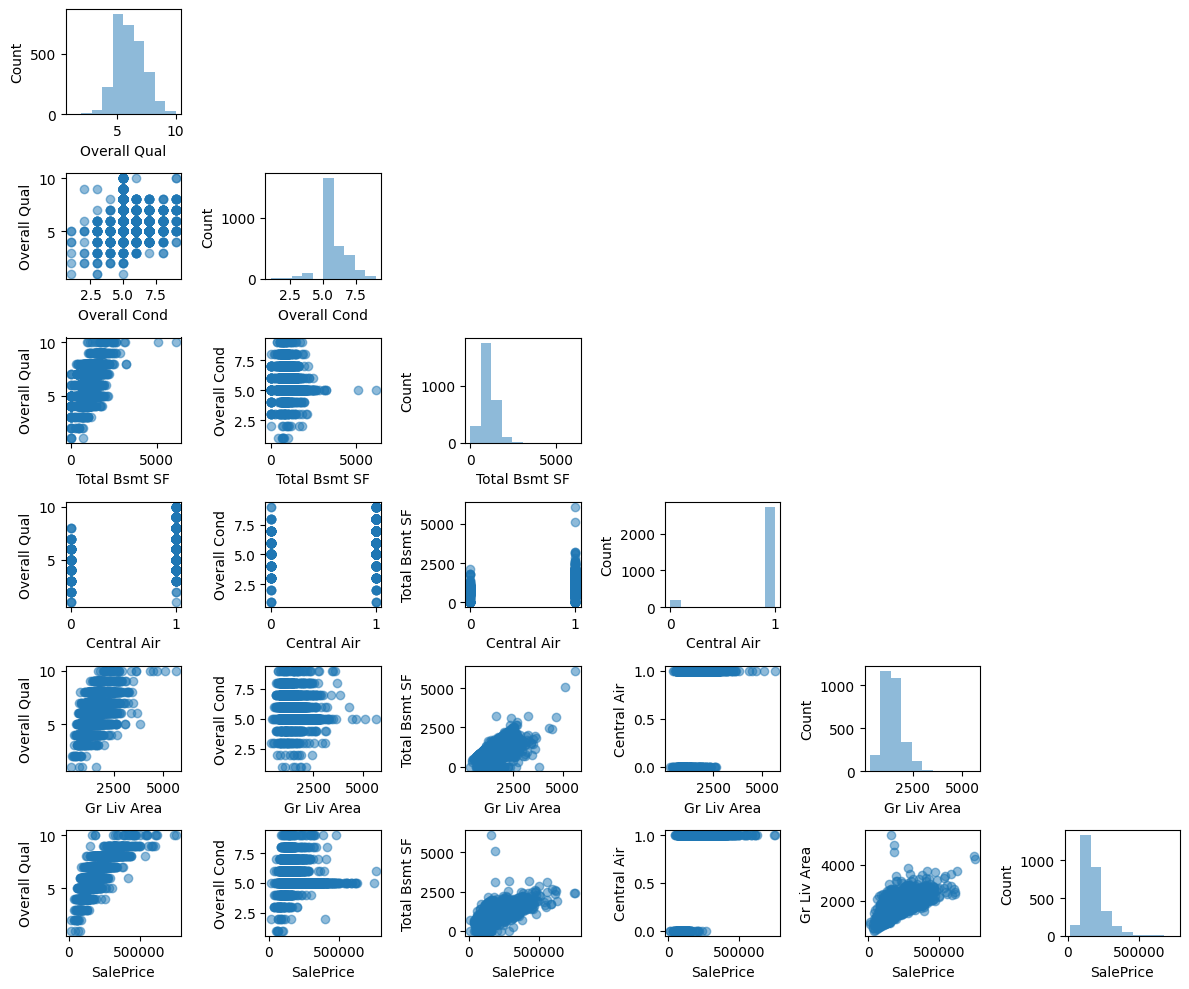

In [8]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize=(12, 10), names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

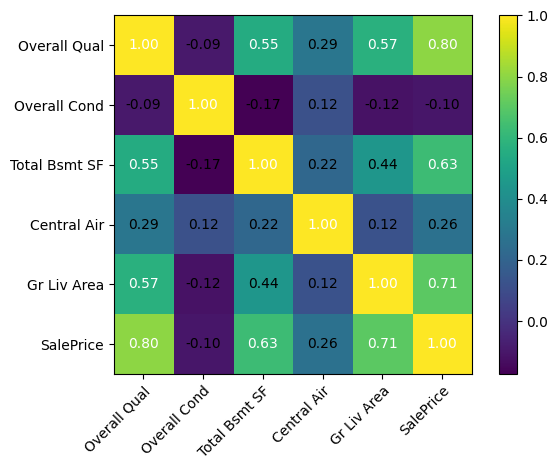

In [9]:
# Calculating Correlation Matrix

import numpy as np
from mlxtend.plotting import heatmap

cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)
plt.tight_layout()
plt.show()

---
### Implementing an ordinary least squares linear regression model

In [10]:
class LinearRegressionGD:
    def __init__(self, lr: float = 0.01, epochs: int = 50, random_state=1) -> None:
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.0])
        self.losses_ = []

        for _ in range(self.epochs):
            output = self.net_input(X)
            errors = y - output

            self.w_ += self.lr * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.lr * 2.0 * errors.mean()

            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

In [32]:
# Using Gr Living Area (size of the living area above ground in square feet) feature
#  as the explanatory variable and train a model that can predict SalePrice.
from sklearn.preprocessing import StandardScaler

X = df[["Gr Liv Area"]].values
y = df["SalePrice"].values

sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
#  use of np.newaxis in y[:, np.newaxis] added a new dimension to the array.
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()  # type: ignore

lr = LinearRegressionGD(lr=0.1)
lr.fit(X_std, y_std)

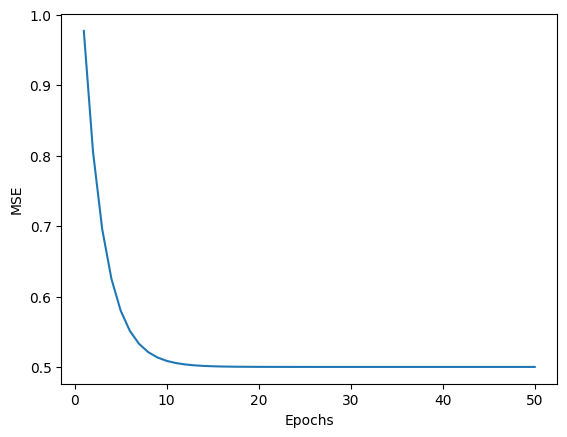

In [33]:
plt.plot(range(1, lr.epochs + 1), lr.losses_)
plt.ylabel("MSE")
plt.xlabel("Epochs")
plt.show()

In [34]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c="steelblue", edgecolors="white", s=70)
    plt.plot(X, model.predict(X), color="black", lw=2)

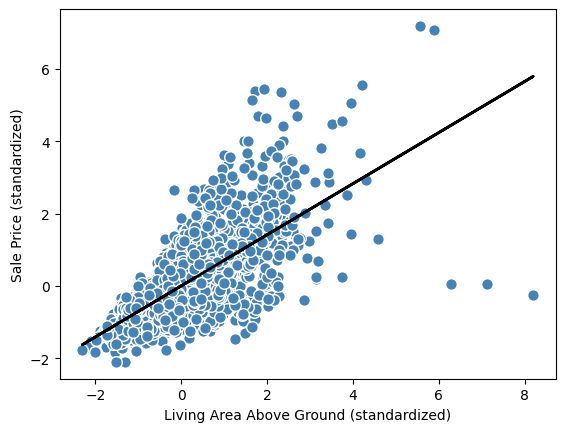

In [35]:
lin_regplot(X_std, y_std, lr)
plt.xlabel("Living Area Above Ground (standardized)")
plt.ylabel("Sale Price (standardized)")
plt.show()

In [36]:
# Predict the price of a house with an aboveground living area of 2,500 square feet.

feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f"Sales price: ${target_reverted.flatten()[0]:.2f}")

Sales price: $292507.07


---
### Estimating the coefficient of a regression model via scikit-learn

In [37]:
from sklearn.linear_model import LinearRegression

slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)

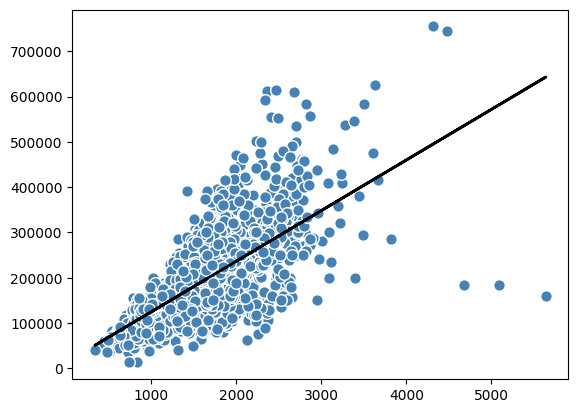

In [38]:
lin_regplot(X, y, slr)


---
### Fitting a robust regression model using RANSAC
We can summarize the iterative RANSAC algorithm as follows:
<small>
1. Select a random number of examples to be inliers and fit the model.
2. Test all other data points against the fitted model and add those points that fall within a user-given tolerance to the inliers.
3. Refit the model using all inliers.
4. Estimate the error of the fitted model versus the inliers.
5. Terminate the algorithm if the performance meets a certain user-defined threshold or if a
fixed number of iterations was reached; go back to step 1 otherwise.
</small>

In [47]:
from sklearn.linear_model import RANSACRegressor

ransac = RANSACRegressor(
    LinearRegression(),
    max_trials=100,
    min_samples=0.95,
    residual_threshold=None,
    random_state=123,
)
ransac.fit(X, y)

RANSACRegressor(estimator=LinearRegression(), min_samples=0.95,
                random_state=123)

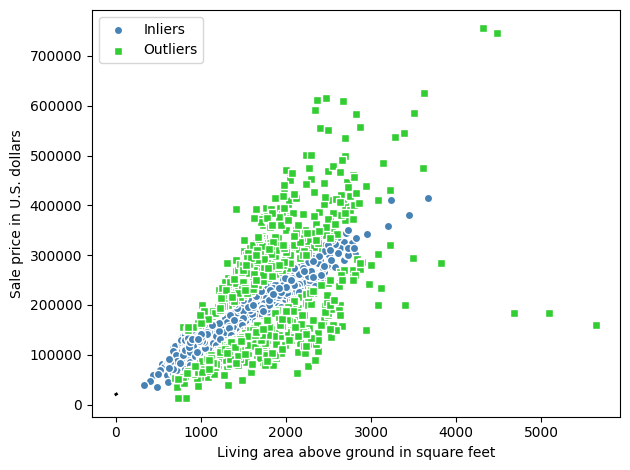

In [48]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

line_X = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])
plt.scatter(
    X[inlier_mask],
    y[inlier_mask],
    c="steelblue",
    edgecolor="white",
    marker="o",
    label="Inliers",
)
plt.scatter(
    X[outlier_mask],
    y[outlier_mask],
    c="limegreen",
    edgecolor="white",
    marker="s",
    label="Outliers",
)
plt.plot(line_X, line_y_ransac, color="black", lw=2)
plt.xlabel("Living area above ground in square feet")
plt.ylabel("Sale price in U.S. dollars")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

---
### Evaluating the performance of linear regression models

In [53]:
from sklearn.model_selection import train_test_split

target = "SalePrice"
features = df.columns[df.columns != target]

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.3, random_state=123
)

In [54]:
slr = LinearRegression()
slr.fit(X_train, y_train)

y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

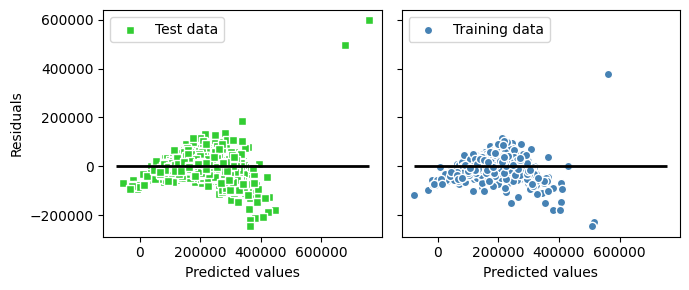

In [55]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(
    y_test_pred,
    y_test_pred - y_test,
    c="limegreen",
    marker="s",
    edgecolor="white",
    label="Test data",
)
ax2.scatter(
    y_train_pred,
    y_train_pred - y_train,
    c="steelblue",
    marker="o",
    edgecolor="white",
    label="Training data",
)
ax1.set_ylabel("Residuals")

for ax in (ax1, ax2):
    ax.set_xlabel("Predicted values")
    ax.legend(loc="upper left")
    ax.hlines(y=0, xmin=x_min - 100, xmax=x_max + 100, color="black", lw=2)

plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MSE Train: {mse_train:.2f}")
print(f"MSE Test: {mse_test:.2f}")

MSE Train: 1535120772.34
MSE Test: 1511547639.35


In [ ]:
from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"MAE train: {mae_train:.2f}")
print(f"MAE test: {mae_test:.2f}")

MAE train: 26670.75
MAE test: 25375.36


<small>
- Based on the test set MAE, we can say that the model makes an error of approximately $25,000 on
average.
</small>

In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"R^2 train: {r2_train:.2f}")
print(f"R^2 test: {r2_test:.2f}")

R^2 train: 0.78
R^2 test: 0.75


---
### Using regularized methods for regression

---
### Modeling nonlinear relationships in the Ames Housing dataset

In [61]:
from sklearn.preprocessing import PolynomialFeatures

In [64]:
# X = df[["Gr Liv Area"]].values
# y = df["SalePrice"].values
X = df[["Overall Qual"]].values
y = df["SalePrice"].values

# remove outliers
X = X[(df["Gr Liv Area"] < 4000)]
y = y[(df["Gr Liv Area"] < 4000)]  # type: ignore

In [65]:
regr = LinearRegression()

# create quadratic and cubic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)

# fit to features
X_fit = np.arange(X.min() - 1, X.max() + 2, 1)[:, np.newaxis]

regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))

regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))

regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))

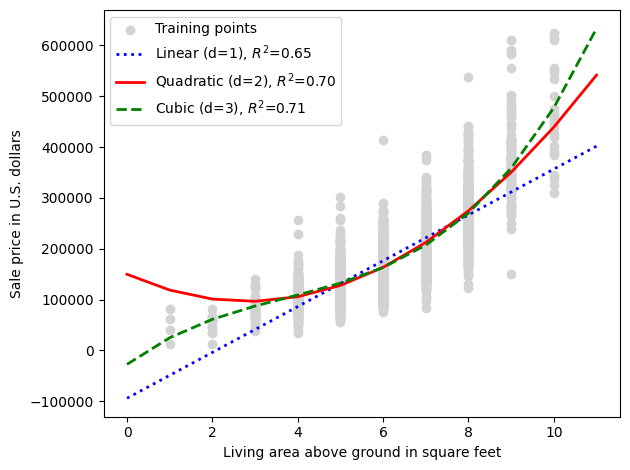

In [66]:
# plot results
plt.scatter(X, y, label="Training points", color="lightgray")

plt.plot(
    X_fit,
    y_lin_fit,
    label=f"Linear (d=1), $R^2$={linear_r2:.2f}",
    color="blue",
    lw=2,
    linestyle=":",
)

plt.plot(
    X_fit,
    y_quad_fit,
    label=f"Quadratic (d=2), $R^2$={quadratic_r2:.2f}",
    color="red",
    lw=2,
    linestyle="-",
)

plt.plot(
    X_fit,
    y_cubic_fit,
    label=f"Cubic (d=3), $R^2$={cubic_r2:.2f}",
    color="green",
    lw=2,
    linestyle="--",
)


plt.xlabel("Living area above ground in square feet")
plt.ylabel("Sale price in U.S. dollars")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

---
### Dealing with nonlinear realtionships using random forests

In [75]:
from sklearn.tree import DecisionTreeRegressor

X = df[["Gr Liv Area"]].values
y = df["SalePrice"].values

tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X, y)

DecisionTreeRegressor(max_depth=5)

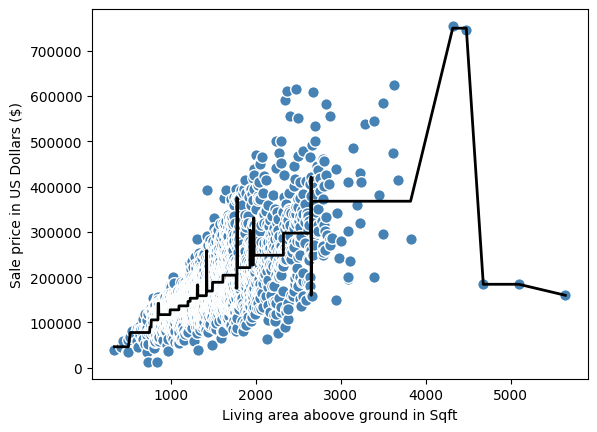

In [76]:
sort_idx = X.flatten().argsort()
lin_regplot(X[sort_idx], y[sort_idx], tree)
plt.xlabel("Living area aboove ground in Sqft")
plt.ylabel("Sale price in US Dollars ($)")
plt.show()

#### Random forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor


forest = RandomForestRegressor(
    n_estimators=1000, criterion="squared_error", random_state=1, n_jobs=-1
)
forest.fit(X_train, y_train)
y_train_pred = forest.predict(X_train)
y_test_pred = forest.predict(X_test)


mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"MAE train: {mae_train:.2f}")
print(f"MAE test: {mae_test:.2f}")


r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"R^2 train: {r2_train:.2f}")
print(f"R^2 test: {r2_test:.2f}")

MAE train: 8520.68
MAE test: 21407.56
R^2 train: 0.97
R^2 test: 0.84


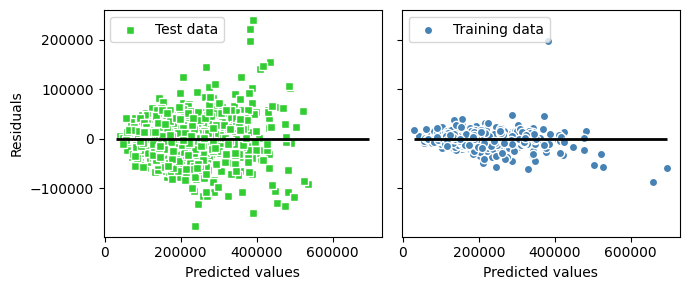

In [78]:
# Residuals of the prediction:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(
    y_test_pred,
    y_test_pred - y_test,
    c="limegreen",
    marker="s",
    edgecolor="white",
    label="Test data",
)
ax2.scatter(
    y_train_pred,
    y_train_pred - y_train,
    c="steelblue",
    marker="o",
    edgecolor="white",
    label="Training data",
)
ax1.set_ylabel("Residuals")

for ax in (ax1, ax2):
    ax.set_xlabel("Predicted values")
    ax.legend(loc="upper left")
    ax.hlines(y=0, xmin=x_min - 100, xmax=x_max + 100, color="black", lw=2)

plt.tight_layout()
plt.show()